<a href="https://colab.research.google.com/github/hansoe01/hansoe01/blob/main/CS527_Project3_Phase2_Rev2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS527 Data Science (Project 3 - Phase 2)
### Submitted by Han Soe and Nay Linn Aung
## Submitted a Jupyter notebook with Python and markdown.

# Predictive Maintenance of Industrial Equipment Using the AI4I 2020 Dataset


## Executive framing

This project studies whether machine failures can be predicted from operating conditions in the AI4I 2020 predictive maintenance dataset and whether individual failure causes can be separated once label inconsistencies are handled carefully.

The notebook addresses three linked questions:

1. Can machine failure be predicted reliably from machine type and process measurements?
2. Do physics-informed engineered features improve the predictive signal?
3. After removing ambiguous labels, can the failure cause be modeled as a defensible multiclass task?


### Two-person contribution table

| Team member | Contribution summary |
| --- | --- |
| `Han Soe` | Project framing, exploratory analysis, multiclass modeling, visual design, and presentation preparation |
| `Nay Linn Aung` | Data preparation, binary modeling, notebook integration, validation checks, and final report polishing |

## Dataset source

- Local runtime file: `ai4i2020.csv`

- Reference sources:
1. S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," in 2020 Third International Conference on Artificial           Intelligence for Industries (AI4I), 2020, p. 69, doi: 10.1109/AI4I49448.2020.00023.
2. A. Torcianti and S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications using a Local Surrogate Model," in 2021 4th     International Conference on Artificial Intelligence for Industries (AI4I), 2021, p. 86, doi: 10.1109/AI4I51902.2021.00029.
3. AI4I 2020 Predictive Maintenance Dataset, UCI Machine Learning Repository.  
   https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset


## Reproducibility notes

- The notebook is fully executable from top to bottom in a local Python environment.
- Model evaluation uses a fixed random seed (`RANDOM_STATE = 42`) for reproducibility.
- The analysis verifies that the local CSV matches the original ZIP archive byte-for-byte when the archive is present; when the archive is not present, the CSV SHA-256 is still reported for auditability.
- The binary task uses a strict **60/20/20** train/validation/test split, while the multiclass task uses a stratified 80/20 split on the cleaned failure-only subset.
- Package versions used for the local execution environment are displayed near the beginning of the notebook.
- Sequence-aware and survival-analysis methods are **not implemented in this notebook**; they are listed explicitly under *Future work* because the AI4I 2020 table is cross-sectional and has no repeated per-asset trajectories or right-censoring information.


In [1]:
# Core imports, notebook-wide constants, and display settings used across every section.

import hashlib
import math
import platform
import sys
import zipfile
from itertools import combinations, product
from pathlib import Path

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import shap
import seaborn as sns
import sklearn
import xgboost
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier


RANDOM_STATE = 42
DATA_PATH = Path("../data/raw/ai4i2020.csv")
ZIP_PATH = Path("../data/raw/ai4i+2020+predictive+maintenance+dataset.zip")

# Failure-mode flags are audited and reused for the cleaned multiclass task,
# but they are never allowed into the binary predictor matrix because they
# describe the outcome rather than the pre-failure operating state.
FAILURE_MODE_COLS = ["TWF", "HDF", "PWF", "OSF", "RNF"]
NON_RNF_FAILURE_COLS = ["TWF", "HDF", "PWF", "OSF"]

# SENSOR_FEATURES is the defensible raw feature set for the main binary task.
SENSOR_FEATURES = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

# These engineered variables mirror the physical rules described in the AI4I papers.
ENGINEERED_FEATURES = ["Temp diff [K]", "Power [W]", "Wear x Torque"]

# Restrict recourse search to features that could plausibly be adjusted in operation.
ACTIONABLE_RECOURSE_FEATURES = [
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Process temperature [K]",
]

# Lower weights indicate relatively cheaper / easier interventions in the search score.
ACTIONABLE_FEATURE_WEIGHTS = {
    "Rotational speed [rpm]": 1.15,
    "Torque [Nm]": 1.00,
    "Tool wear [min]": 0.85,
    "Process temperature [K]": 1.30,
}


# Standardize the visual style so plots from different sections are directly comparable.
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
# Helper functions for feature engineering, preprocessing, and binary model definitions.

def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    engineered = frame.copy()

    # The temperature gap approximates the heat-dissipation relationship in the source dataset.
    engineered["Temp diff [K]"] = (
        engineered["Process temperature [K]"] - engineered["Air temperature [K]"]
    )

    # Power combines torque and rotational speed into a single energy-related signal.
    engineered["Power [W]"] = (
        engineered["Torque [Nm]"] * (2 * math.pi * engineered["Rotational speed [rpm]"] / 60)
    )

    # Wear-load coupling helps expose the overstrain mechanism in a simple interaction term.
    engineered["Wear x Torque"] = (
        engineered["Tool wear [min]"] * engineered["Torque [Nm]"]
    )
    return engineered


def build_preprocessor(frame: pd.DataFrame) -> ColumnTransformer:
    # Split numeric vs categorical columns so each type gets the correct transformation path.
    numeric_cols = frame.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = frame.select_dtypes(exclude=["number"]).columns.tolist()
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        # Median imputation + scaling keeps linear models stable and is harmless for trees.
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            # One-hot encoding preserves machine-type membership without inventing order.
                            "encoder",
                            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ],
        remainder="drop",
        sparse_threshold=0,
    )


def build_binary_models(pos_weight: float) -> dict:
    return {
        # Interpretable linear baseline.
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        # Non-linear bagging baseline with class rebalancing inside each bootstrap sample.
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
        ),
        # Gradient boosting gets an explicit positive-class weight estimated from the training split.
        "XGBoost": XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=4,
            scale_pos_weight=pos_weight,
        ),
    }


In [3]:
# Helper functions for multiclass modeling, evaluation, explainability, and recourse.

def build_multiclass_models(num_classes: int) -> dict:
    # Both multiclass candidates share the same preprocessing so the comparison isolates the classifier choice.
    return {
        "Multinomial Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Multiclass XGBoost": XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="multi:softprob",
            num_class=num_classes,
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=4,
        ),
    }


def make_pipeline(frame: pd.DataFrame, model) -> Pipeline:
    # Wrap preprocessing and model fitting together so every split uses the same learned transformations.
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(frame)),
            ("model", model),
        ]
    )


def binary_metrics(y_true: pd.Series, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    # ROC-AUC / PR-AUC are threshold-free, while F1 / precision / recall depend on the deployment cutoff.
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def tune_threshold(y_true: pd.Series, y_prob: np.ndarray) -> pd.DataFrame:
    # Threshold search is confined to validation predictions so the test split remains an honest final check.
    thresholds = np.arange(0.10, 0.95, 0.05)
    rows = []
    for threshold in thresholds:
        metrics = binary_metrics(y_true, y_prob, threshold=threshold)
        rows.append(
            {
                "Threshold": threshold,
                "F1": metrics["F1"],
                "Precision": metrics["Precision"],
                "Recall": metrics["Recall"],
            }
        )
    return pd.DataFrame(rows).sort_values(["F1", "Precision"], ascending=False).reset_index(drop=True)


def report_frame(y_true, y_pred) -> pd.DataFrame:
    # Convert sklearn's nested classification report dictionary into a display-friendly table.
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    rows = []
    total_support = len(y_true)
    for label, values in report.items():
        if isinstance(values, dict):
            rows.append({"Class": label, **values})
        else:
            rows.append(
                {
                    "Class": label,
                    "precision": np.nan,
                    "recall": np.nan,
                    "f1-score": float(values),
                    "support": total_support,
                }
            )
    return pd.DataFrame(rows)


def threshold_metrics_frame(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    # Used later for subgroup comparisons after the final binary threshold has been fixed.
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def plot_confusion(ax, matrix: np.ndarray, labels: list, title: str) -> None:
    # Shared plotting helper keeps binary and multiclass confusion matrices visually aligned.
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")


def top_coefficient_table(model_pipeline: Pipeline, top_n: int = 5) -> pd.DataFrame:
    # For multinomial logistic regression, report the strongest positive coefficients per class.
    preprocess = model_pipeline.named_steps["preprocess"]
    model = model_pipeline.named_steps["model"]
    feature_names = preprocess.get_feature_names_out()
    coefficient_frame = pd.DataFrame(
        model.coef_.T,
        index=feature_names,
        columns=model.classes_,
    )
    rows = []
    for class_name in coefficient_frame.columns:
        top_features = coefficient_frame[class_name].sort_values(ascending=False).head(top_n)
        for feature_name, value in top_features.items():
            rows.append(
                {
                    "Class": class_name,
                    "Feature": feature_name,
                    "Coefficient": value,
                }
            )
    return pd.DataFrame(rows)


def build_clean_failure_subset(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    working = frame.copy()

    # Start from rows that truly failed, then count how many interpretable non-RNF causes are active.
    failure_rows = working[working["Machine failure"] == 1].copy()
    failure_rows["non_rnf_mode_count"] = failure_rows[NON_RNF_FAILURE_COLS].sum(axis=1)

    # RNF is treated as descriptive inconsistency here rather than a clean multiclass label.
    rnf_flagged_failures = failure_rows[failure_rows["RNF"] == 1]
    remaining_failures = failure_rows[failure_rows["RNF"] == 0]
    zero_mode_failures = remaining_failures[remaining_failures["non_rnf_mode_count"] == 0]
    multi_mode_failures = remaining_failures[remaining_failures["non_rnf_mode_count"] > 1]

    # Keep only rows with exactly one valid non-RNF cause so the multiclass target stays single-label.
    clean_failures = remaining_failures[remaining_failures["non_rnf_mode_count"] == 1].copy()
    clean_failures["Failure cause"] = clean_failures[NON_RNF_FAILURE_COLS].idxmax(axis=1)

    # This audit table makes every retained and excluded group explicit in the notebook output.
    exclusion_summary = pd.DataFrame(
        [
            {"Stage": "Total dataset rows", "Rows": len(working)},
            {"Stage": "Rows with Machine failure = 1", "Rows": len(failure_rows)},
            {"Stage": "Retained clean single-cause failures", "Rows": len(clean_failures)},
            {
                "Stage": "Excluded failure rows with zero non-RNF cause labels",
                "Rows": len(zero_mode_failures),
            },
            {
                "Stage": "Excluded failure rows with multiple non-RNF cause labels",
                "Rows": len(multi_mode_failures),
            },
            {
                "Stage": "Excluded failure rows with RNF flagged",
                "Rows": len(rnf_flagged_failures),
            },
            {
                "Stage": "RNF-marked rows with Machine failure = 0 (descriptive inconsistency)",
                "Rows": int(((working["Machine failure"] == 0) & (working["RNF"] == 1)).sum()),
            },
        ]
    )
    return clean_failures, exclusion_summary


def group_feature_name(feature_name: str) -> str:
    # Collapse one-hot encoded names back to their original source feature for grouped SHAP summaries.
    raw_name = feature_name.split("__", 1)[-1]
    if raw_name.startswith("Type_"):
        return "Type"
    return raw_name


def positive_class_shap_values(explainer, transformed_frame: np.ndarray) -> np.ndarray:
    # Different SHAP explainers emit different tensor shapes; normalize everything to positive-class contributions.
    shap_values = np.asarray(explainer.shap_values(transformed_frame))
    if shap_values.ndim == 3:
        return shap_values[:, :, 1]
    if shap_values.ndim == 2:
        return shap_values
    raise ValueError(f"Unexpected SHAP output shape: {shap_values.shape}")


def sample_explainer_background(transformed_frame: np.ndarray, max_rows: int = 256) -> np.ndarray:
    # Cap the background size so explanation generation stays stable without becoming too slow.
    values = np.asarray(transformed_frame)
    if values.shape[0] <= max_rows:
        return values
    rng = np.random.default_rng(RANDOM_STATE)
    sampled_idx = np.sort(rng.choice(values.shape[0], size=max_rows, replace=False))
    return values[sampled_idx]


def build_binary_shap_explainer(model, transformed_train: np.ndarray):
    # Match the explainer implementation to the fitted model family.
    background = sample_explainer_background(transformed_train)
    if isinstance(model, LogisticRegression):
        return shap.LinearExplainer(model, background)
    if isinstance(model, (RandomForestClassifier, XGBClassifier)):
        return shap.TreeExplainer(model)
    raise TypeError(f"Unsupported model type for SHAP explanations: {type(model)!r}")


def build_feature_frame(raw_sensor_frame: pd.DataFrame, feature_set_name: str) -> pd.DataFrame:
    # Toggle engineered features on/off using the same convention as the model-comparison stage.
    base_frame = raw_sensor_frame[SENSOR_FEATURES].copy()
    if feature_set_name == "Engineered features":
        return add_engineered_features(base_frame)
    return base_frame


def grouped_shap_frame(shap_values: np.ndarray, feature_names: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Sum one-hot encoded contributions back into original feature groups for cleaner global interpretation.
    feature_frame = pd.DataFrame(shap_values, columns=feature_names)
    grouped = pd.DataFrame(index=feature_frame.index)
    for group_name in sorted({group_feature_name(name) for name in feature_names}):
        grouped[group_name] = feature_frame.loc[
            :,
            [name for name in feature_names if group_feature_name(name) == group_name],
        ].sum(axis=1)
    summary = (
        grouped.abs()
        .mean()
        .sort_values(ascending=False)
        .rename_axis("Feature group")
        .reset_index(name="Mean |SHAP|")
    )
    return grouped, summary


def intervention_scale(reference_frame: pd.DataFrame, feature_name: str) -> float:
    # Normalize intervention size by IQR so different units can share a single intervention score.
    q25, q75 = reference_frame[feature_name].quantile([0.25, 0.75])
    scale = float(q75 - q25)
    return scale if scale > 0 else max(float(reference_frame[feature_name].std()), 1.0)


def candidate_feature_values(reference_frame: pd.DataFrame, raw_row: pd.Series, feature_name: str) -> list[float]:
    # Search a compact grid of empirically observed quantiles rather than brute-forcing arbitrary real values.
    current_value = float(raw_row[feature_name])
    quantile_points = [0.05, 0.10, 0.25, 0.40, 0.50, 0.60, 0.75, 0.90, 0.95]
    values = sorted({round(float(reference_frame[feature_name].quantile(point)), 4) for point in quantile_points})

    if feature_name == "Tool wear [min]":
        # Tool replacement is modeled as moving wear downward, including a full reset to 0.
        candidate_values = [0.0, *values]
        return [value for value in candidate_values if value < current_value]

    if feature_name == "Torque [Nm]":
        return [value for value in values if value < current_value]

    if feature_name == "Process temperature [K]":
        return [value for value in values if value < current_value]

    # Rotational speed is allowed to move in either direction if it differs from the current setting.
    return [value for value in values if not math.isclose(value, current_value)]


def recourse_action_text(original_row: pd.Series, candidate_row: pd.Series) -> str:
    # Translate numeric deltas into maintenance-oriented language for the final action table.
    actions = []
    for feature_name in ACTIONABLE_RECOURSE_FEATURES:
        old_value = float(original_row[feature_name])
        new_value = float(candidate_row[feature_name])
        if math.isclose(old_value, new_value):
            continue

        if feature_name == "Tool wear [min]":
            actions.append(f"Replace or reset the tool ({old_value:.0f} -> {new_value:.0f} min).")
        elif feature_name == "Torque [Nm]":
            actions.append(f"Reduce torque load ({old_value:.1f} -> {new_value:.1f} Nm).")
        elif feature_name == "Rotational speed [rpm]":
            verb = "Increase" if new_value > old_value else "Reduce"
            actions.append(f"{verb} rotational speed ({old_value:.0f} -> {new_value:.0f} rpm).")
        elif feature_name == "Process temperature [K]":
            verb = "Increase" if new_value > old_value else "Lower"
            actions.append(f"{verb} process temperature ({old_value:.1f} -> {new_value:.1f} K).")
    return " ".join(actions)


def search_counterfactual_recourse(
    estimator,
    raw_row: pd.Series,
    reference_raw_frame: pd.DataFrame,
    feature_set_name: str,
    model_columns: list[str],
    target_threshold: float,
    max_features_to_change: int = 2,
) -> pd.DataFrame:
    # Score the original case under the same feature-set convention used by the selected model.
    raw_reference = reference_raw_frame[SENSOR_FEATURES].copy()
    base_raw = raw_row[SENSOR_FEATURES].copy()
    base_model_frame = build_feature_frame(base_raw.to_frame().T, feature_set_name)[model_columns]
    baseline_probability = float(estimator.predict_proba(base_model_frame)[:, 1][0])

    # Pre-compute admissible candidate values for each actionable variable from the observed reference distribution.
    candidate_grid = {
        feature_name: candidate_feature_values(raw_reference, base_raw, feature_name)
        for feature_name in ACTIONABLE_RECOURSE_FEATURES
    }

    rows = []

    # Search only one- and two-feature interventions so the resulting actions remain operationally simple.
    for num_changes in range(1, max_features_to_change + 1):
        for feature_subset in combinations(ACTIONABLE_RECOURSE_FEATURES, num_changes):
            feature_value_lists = []
            skip_subset = False
            for feature_name in feature_subset:
                values = candidate_grid[feature_name]
                if not values:
                    # If any feature has no feasible alternatives, this subset cannot produce recourse.
                    skip_subset = True
                    break
                feature_value_lists.append(values)
            if skip_subset:
                continue

            for assignments in product(*feature_value_lists):
                candidate_raw = base_raw.copy()
                for feature_name, value in zip(feature_subset, assignments):
                    candidate_raw[feature_name] = value

                # Pass the counterfactual through the fitted pipeline so preprocessing remains identical.
                candidate_model_frame = build_feature_frame(candidate_raw.to_frame().T, feature_set_name)[model_columns]
                candidate_probability = float(estimator.predict_proba(candidate_model_frame)[:, 1][0])
                if candidate_probability >= target_threshold:
                    # Keep only interventions that move the case below the chosen deployment threshold.
                    continue

                intervention_cost = 0.0
                for feature_name in feature_subset:
                    intervention_cost += (
                        ACTIONABLE_FEATURE_WEIGHTS[feature_name]
                        * abs(float(candidate_raw[feature_name]) - float(base_raw[feature_name]))
                        / intervention_scale(raw_reference, feature_name)
                    )

                rows.append(
                    {
                        "Features changed": ", ".join(feature_subset),
                        "Counterfactual probability": candidate_probability,
                        "Probability reduction": baseline_probability - candidate_probability,
                        "Intervention score": intervention_cost,
                        "Action plan": recourse_action_text(base_raw, candidate_raw),
                    }
                )

    if not rows:
        # Surface a clear fallback message when no compact counterfactual intervention is feasible.
        return pd.DataFrame(
            [
                {
                    "Features changed": "No feasible <=2-feature recourse found",
                    "Counterfactual probability": np.nan,
                    "Probability reduction": np.nan,
                    "Intervention score": np.nan,
                    "Action plan": "A broader engineering intervention or human review is required.",
                }
            ]
        )

    return (
        pd.DataFrame(rows)
        .sort_values(["Intervention score", "Counterfactual probability", "Probability reduction"], ascending=[True, True, False])
        .drop_duplicates(subset=["Features changed", "Action plan"])
        .reset_index(drop=True)
    )


In [4]:
# Capture the exact runtime environment for reproducibility and grading.

environment_manifest = pd.DataFrame(
    [
        {"Component": "Python", "Version": sys.version.split()[0]},
        {"Component": "Platform", "Version": platform.platform()},
        {"Component": "pandas", "Version": pd.__version__},
        {"Component": "numpy", "Version": np.__version__},
        {"Component": "scikit-learn", "Version": sklearn.__version__},
        {"Component": "shap", "Version": shap.__version__},
        {"Component": "xgboost", "Version": xgboost.__version__},
        {"Component": "matplotlib", "Version": plt.matplotlib.__version__},
        {"Component": "seaborn", "Version": sns.__version__},
        {"Component": "nbformat", "Version": nbformat.__version__},
    ]
)

display(environment_manifest)


,Component,Version
0,Python,3.12.13
1,Platform,Linux-6.6.113+-x86_64-with-glibc2.35
2,pandas,2.2.2
3,numpy,2.0.2
4,scikit-learn,1.6.1
5,shap,0.51.0
6,xgboost,3.2.0
7,matplotlib,3.10.0
8,seaborn,0.13.2
9,nbformat,5.10.4


In [5]:
import requests

# Create the data directory if it doesn't exist
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

# Download the CSV file
csv_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
response = requests.get(csv_url)
response.raise_for_status() # Raise an exception for HTTP errors

with open(DATA_PATH, "wb") as f:
    f.write(response.content)

print(f"Downloaded {DATA_PATH.name} to {DATA_PATH.parent}/")

Downloaded ai4i2020.csv to ../data/raw/


In [6]:
# Load the local CSV and record hashes so the notebook documents exactly which dataset snapshot was used.

df = pd.read_csv(DATA_PATH)

with open(DATA_PATH, "rb") as csv_file:
    csv_bytes = csv_file.read()
csv_sha256 = hashlib.sha256(csv_bytes).hexdigest()

# When the original ZIP archive is available, verify the extracted CSV matches byte-for-byte.
if ZIP_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH) as archive:
        zipped_bytes = archive.read("ai4i2020.csv")
    zip_sha256 = hashlib.sha256(zipped_bytes).hexdigest()
    zip_status = "Matches byte-for-byte" if csv_bytes == zipped_bytes else "MISMATCH"
else:
    zip_sha256 = "Archive not present for this run"
    zip_status = "Archive not present for this run"

# Report dataset size, class balance, and integrity metadata before any modeling begins.
dataset_overview = pd.DataFrame(
    [
        {"Item": "Rows", "Value": len(df)},
        {"Item": "Columns", "Value": df.shape[1]},
        {"Item": "Machine failure rate", "Value": f"{df['Machine failure'].mean():.2%}"},
        {"Item": "ZIP vs CSV integrity check", "Value": zip_status},
        {"Item": "CSV SHA-256", "Value": csv_sha256},
        {"Item": "ZIP member SHA-256", "Value": zip_sha256},
    ]
)

# A compact column dictionary makes later feature-selection decisions easy to audit.
column_dictionary = pd.DataFrame(
    [
        {"Column": "UDI", "Description": "Unique record identifier", "Project use": "Exclude from modeling"},
        {"Column": "Product ID", "Description": "Product code with type prefix", "Project use": "Exclude from modeling"},
        {"Column": "Type", "Description": "Product quality category (L, M, H)", "Project use": "Predictor"},
        {"Column": "Air temperature [K]", "Description": "Ambient air temperature", "Project use": "Predictor"},
        {"Column": "Process temperature [K]", "Description": "Internal process temperature", "Project use": "Predictor"},
        {"Column": "Rotational speed [rpm]", "Description": "Rotational speed of the machine", "Project use": "Predictor"},
        {"Column": "Torque [Nm]", "Description": "Applied torque", "Project use": "Predictor"},
        {"Column": "Tool wear [min]", "Description": "Accumulated tool wear time", "Project use": "Predictor"},
        {"Column": "Machine failure", "Description": "Primary binary target", "Project use": "Binary target"},
        {"Column": "TWF/HDF/PWF/OSF/RNF", "Description": "Failure-mode labels", "Project use": "Leakage risk for binary task; target-side metadata"},
    ]
)

display(dataset_overview)
display(column_dictionary)
display(df.head())


,Item,Value
0,Rows,10000
1,Columns,14
2,Machine failure rate,3.39%
3,ZIP vs CSV integrity check,Archive not present for this run
4,CSV SHA-256,dc6630cd9b1f0f853922fad78a1b6436570d3f1ec863f1...
5,ZIP member SHA-256,Archive not present for this run


,Column,Description,Project use
0,UDI,Unique record identifier,Exclude from modeling
1,Product ID,Product code with type prefix,Exclude from modeling
2,Type,"Product quality category (L, M, H)",Predictor
3,Air temperature [K],Ambient air temperature,Predictor
4,Process temperature [K],Internal process temperature,Predictor
5,Rotational speed [rpm],Rotational speed of the machine,Predictor
6,Torque [Nm],Applied torque,Predictor
7,Tool wear [min],Accumulated tool wear time,Predictor
8,Machine failure,Primary binary target,Binary target
9,TWF/HDF/PWF/OSF/RNF,Failure-mode labels,Leakage risk for binary task; target-side meta...


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1000,308.6000,1551,42.8000,0,0,0,0,0,0,0
1,2,L47181,L,298.2000,308.7000,1408,46.3000,3,0,0,0,0,0,0
2,3,L47182,L,298.1000,308.5000,1498,49.4000,5,0,0,0,0,0,0
3,4,L47183,L,298.2000,308.6000,1433,39.5000,7,0,0,0,0,0,0
4,5,L47184,L,298.2000,308.7000,1408,40.0000,9,0,0,0,0,0,0


## 1. Data provenance, audit, and modeling assumptions

Before training any model, the dataset must be audited for leakage, identifier columns, and label consistency. This is especially important here because the file contains both a binary failure target (`Machine failure`) and five failure-mode labels (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`).

For the **binary task**, the failure-mode flags are treated as target-side information and are **not** allowed to enter the predictor set. The identifier columns `UDI` and `Product ID` are also removed from modeling because they are not causal operating variables.

In [7]:
# Audit every column to distinguish identifiers, valid predictors, and target-side leakage risks.

column_role_rows = []
for column in df.columns:
    if column in {"UDI", "Product ID"}:
        role = "Identifier"
        modeling_use = "Exclude"
        reason = "Identifiers, not causal process measurements."
    elif column == "Machine failure":
        role = "Primary target"
        modeling_use = "Binary target"
        reason = "Main target for the predictive maintenance task."
    elif column in FAILURE_MODE_COLS:
        role = "Secondary target / leakage risk"
        modeling_use = "Exclude from binary features"
        reason = "Failure labels are outcome-side variables, not valid predictors."
    else:
        role = "Feature"
        modeling_use = "Include"
        reason = "Sensor or machine-condition input."
    column_role_rows.append(
        {
            "Column": column,
            "Role": role,
            "Modeling use": modeling_use,
            "Reason": reason,
        }
    )

# These checks document that the file is clean and that the identifier fields behave as expected.
audit_summary = pd.DataFrame(
    [
        {"Check": "Missing cells", "Value": int(df.isna().sum().sum())},
        {"Check": "Duplicate rows", "Value": int(df.duplicated().sum())},
        {"Check": "Duplicate UDI values", "Value": int(df["UDI"].duplicated().sum())},
        {"Check": "Duplicate Product ID values", "Value": int(df["Product ID"].duplicated().sum())},
        {
            "Check": "Product ID prefix matches Type for every row",
            "Value": bool((df["Product ID"].str[0] == df["Type"]).all()),
        },
    ]
)

display(pd.DataFrame(column_role_rows))
display(audit_summary)


,Column,Role,Modeling use,Reason
0,UDI,Identifier,Exclude,"Identifiers, not causal process measurements."
1,Product ID,Identifier,Exclude,"Identifiers, not causal process measurements."
2,Type,Feature,Include,Sensor or machine-condition input.
3,Air temperature [K],Feature,Include,Sensor or machine-condition input.
4,Process temperature [K],Feature,Include,Sensor or machine-condition input.
5,Rotational speed [rpm],Feature,Include,Sensor or machine-condition input.
6,Torque [Nm],Feature,Include,Sensor or machine-condition input.
7,Tool wear [min],Feature,Include,Sensor or machine-condition input.
8,Machine failure,Primary target,Binary target,Main target for the predictive maintenance task.
9,TWF,Secondary target / leakage risk,Exclude from binary features,"Failure labels are outcome-side variables, not..."


,Check,Value
0,Missing cells,0
1,Duplicate rows,0
2,Duplicate UDI values,0
3,Duplicate Product ID values,0
4,Product ID prefix matches Type for every row,True


In [8]:
# Inspect how the five failure-mode flags align with the main binary target.

failure_mode_counts = pd.DataFrame(
    {
        "All rows": df[FAILURE_MODE_COLS].sum(),
        "Machine failure = 1": df.loc[df["Machine failure"] == 1, FAILURE_MODE_COLS].sum(),
        "Machine failure = 0": df.loc[df["Machine failure"] == 0, FAILURE_MODE_COLS].sum(),
    }
).reset_index().rename(columns={"index": "Failure label"})

failed_rows = df[df["Machine failure"] == 1].copy()

# Count active labels per failed row to expose ambiguous or inconsistent target-side annotations.
failed_rows["active_failure_labels"] = failed_rows[FAILURE_MODE_COLS].sum(axis=1)
failed_rows["active_non_rnf_labels"] = failed_rows[NON_RNF_FAILURE_COLS].sum(axis=1)

# This summary motivates the later cleaning rule for the multiclass failure-cause task.
consistency_summary = pd.DataFrame(
    [
        {"Observation": "Rows with Machine failure = 1", "Count": len(failed_rows)},
        {
            "Observation": "Failed rows with zero active failure-mode labels",
            "Count": int((failed_rows["active_failure_labels"] == 0).sum()),
        },
        {
            "Observation": "Failed rows with multiple active failure-mode labels",
            "Count": int((failed_rows["active_failure_labels"] > 1).sum()),
        },
        {
            "Observation": "Rows with RNF = 1 and Machine failure = 0",
            "Count": int(((df["RNF"] == 1) & (df["Machine failure"] == 0)).sum()),
        },
        {
            "Observation": "Rows with RNF = 1 and Machine failure = 1",
            "Count": int(((df["RNF"] == 1) & (df["Machine failure"] == 1)).sum()),
        },
    ]
)

display(failure_mode_counts)
display(consistency_summary)


,Failure label,All rows,Machine failure = 1,Machine failure = 0
0,TWF,46,46,0
1,HDF,115,115,0
2,PWF,95,95,0
3,OSF,98,98,0
4,RNF,19,1,18


,Observation,Count
0,Rows with Machine failure = 1,339
1,Failed rows with zero active failure-mode labels,9
2,Failed rows with multiple active failure-mode ...,24
3,Rows with RNF = 1 and Machine failure = 0,18
4,Rows with RNF = 1 and Machine failure = 1,1


## 2. Exploratory data analysis

The exploratory analysis focuses on class imbalance, product-type composition, operating-condition differences, and correlations among the numeric process variables. The binary target is highly imbalanced, so precision-recall metrics will be more informative than accuracy alone.

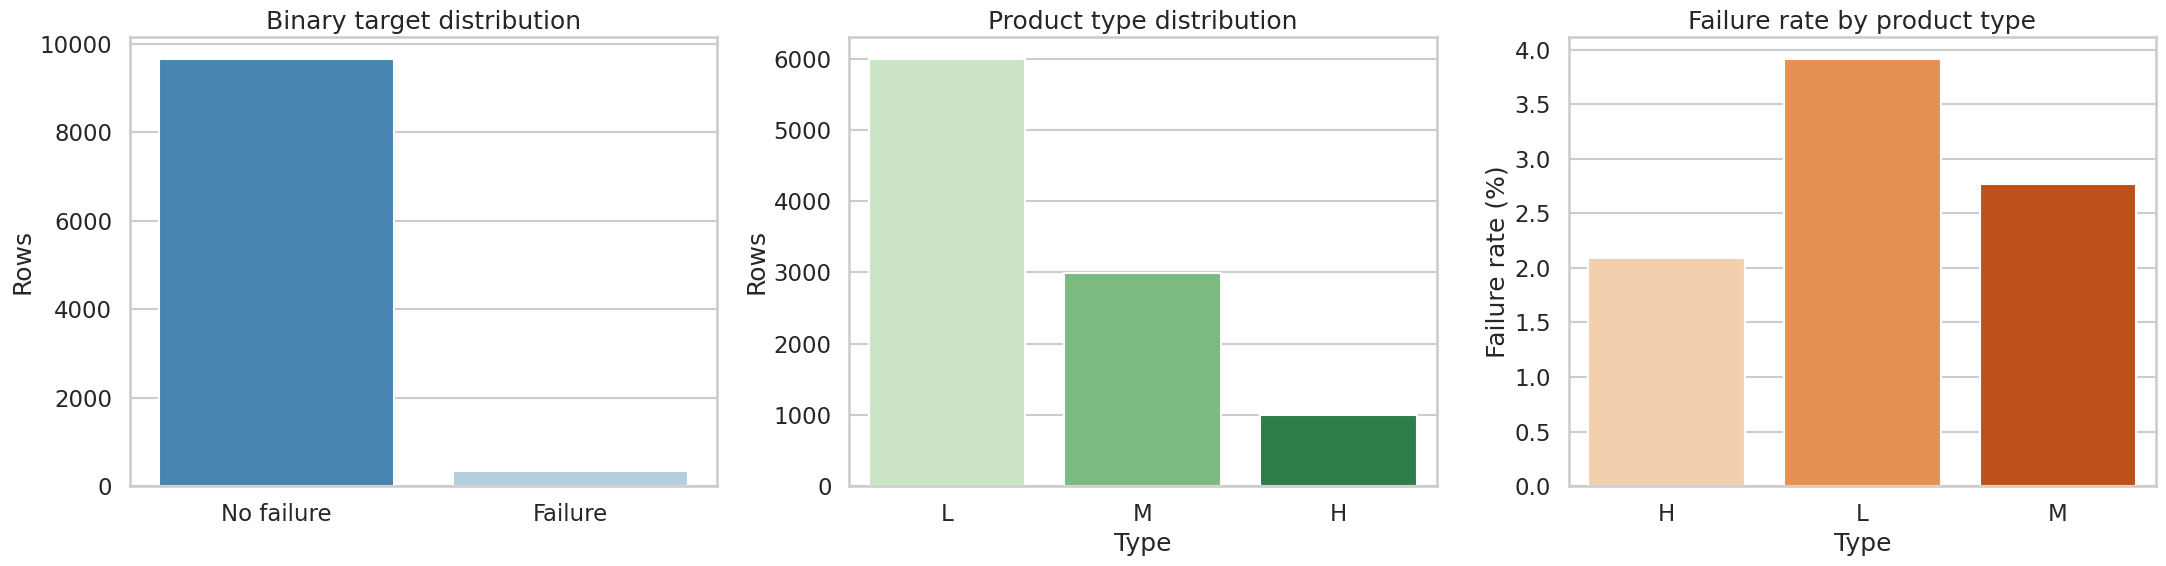

In [9]:
# Build an EDA frame with engineered features so descriptive plots and later models use the same concepts.

eda_df = add_engineered_features(df[SENSOR_FEATURES])
eda_df["Machine failure"] = df["Machine failure"].values

failure_rate_by_type = (
    df.groupby("Type")["Machine failure"]
    .agg(Failure_rate="mean", Failures="sum", Count="count")
    .reset_index()
)
failure_rate_by_type["Failure_rate"] = failure_rate_by_type["Failure_rate"] * 100

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Failures are rare, so visualizing the imbalance early explains why PR-focused metrics matter later.
target_counts = df["Machine failure"].value_counts().sort_index()
sns.barplot(
    x=["No failure", "Failure"],
    y=target_counts.values,
    hue=["No failure", "Failure"],
    palette="Blues_r",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Binary target distribution")
axes[0].set_ylabel("Rows")

# Compare overall product mix before looking at performance by type.
type_counts = df["Type"].value_counts().reindex(["L", "M", "H"])
sns.barplot(
    x=type_counts.index,
    y=type_counts.values,
    hue=type_counts.index,
    palette="Greens",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Product type distribution")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Rows")

# Failure rate by type complements the raw counts by showing whether risk differs across categories.
sns.barplot(
    data=failure_rate_by_type,
    x="Type",
    y="Failure_rate",
    hue="Type",
    palette="Oranges",
    legend=False,
    ax=axes[2],
)
axes[2].set_title("Failure rate by product type")
axes[2].set_ylabel("Failure rate (%)")

plt.tight_layout()
plt.show()


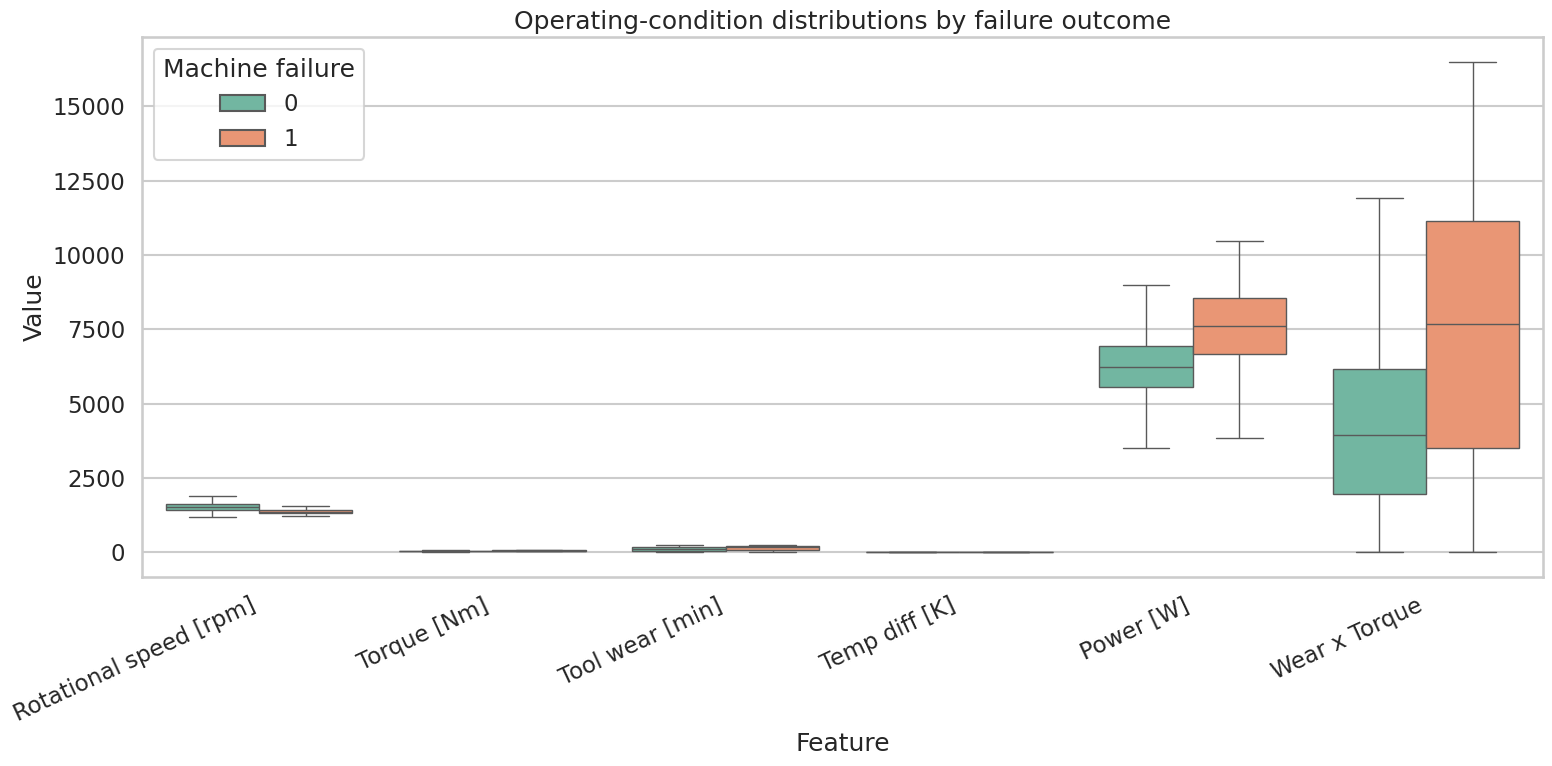

In [10]:
# Compare failed vs non-failed operating conditions to see where the classes separate most clearly.

plot_columns = [
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temp diff [K]",
    "Power [W]",
    "Wear x Torque",
]

# Melt to long format so one shared boxplot can summarize several raw and engineered variables together.
melted = eda_df[plot_columns + ["Machine failure"]].melt(
    id_vars="Machine failure",
    var_name="Feature",
    value_name="Value",
)

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=melted,
    x="Feature",
    y="Value",
    hue="Machine failure",
    palette="Set2",
    showfliers=False,
)
plt.xticks(rotation=25, ha="right")
plt.title("Operating-condition distributions by failure outcome")
plt.tight_layout()
plt.show()


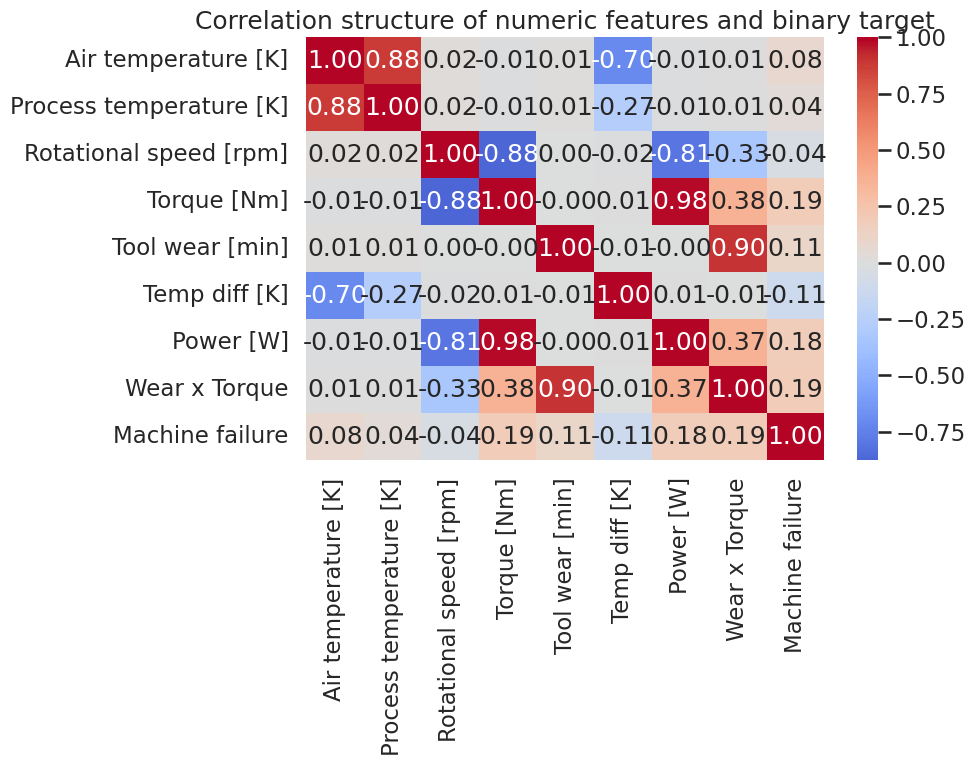

In [11]:
# Correlations help show where engineered variables overlap with the raw thermal and load measurements.

correlation_frame = add_engineered_features(df[SENSOR_FEATURES[1:]].copy())
correlation_frame["Machine failure"] = df["Machine failure"]

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_frame.corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
)
plt.title("Correlation structure of numeric features and binary target")
plt.tight_layout()
plt.show()


## 3. Feature engineering and modeling workflow

Three engineered variables are added to make the models reflect the dataset's underlying synthetic failure rules and the physical behavior they are trying to approximate:

- `Temp diff [K]` captures the temperature gap used in the heat dissipation failure rule.
- `Power [W]` combines torque and rotational speed into an energy-related quantity.
- `Wear x Torque` captures the stress mechanism behind overstrain.

The binary task uses a strict **60/20/20** train/validation/test split. The validation split is used to compare candidate models and to tune the final classification threshold. The test split stays untouched until the final report so that the final metrics remain honest.

The next code cells keep those stages explicit: fixed data splits, candidate-model comparison, validation-only threshold tuning, and then final test reporting.


In [12]:
# Create a strict 60/20/20 split so every candidate model is compared on identical train/validation/test rows.

index_train, index_temp = train_test_split(
    df.index,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=df["Machine failure"],
)
index_val, index_test = train_test_split(
    index_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=df.loc[index_temp, "Machine failure"],
)

y_binary = df["Machine failure"]

# Display class balance in each split to verify that stratification preserved the rare positive class.
split_summary = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Rows": len(index_train),
            "Failures": int(y_binary.loc[index_train].sum()),
            "Failure rate": y_binary.loc[index_train].mean(),
        },
        {
            "Split": "Validation",
            "Rows": len(index_val),
            "Failures": int(y_binary.loc[index_val].sum()),
            "Failure rate": y_binary.loc[index_val].mean(),
        },
        {
            "Split": "Test",
            "Rows": len(index_test),
            "Failures": int(y_binary.loc[index_test].sum()),
            "Failure rate": y_binary.loc[index_test].mean(),
        },
    ]
)
display(split_summary)

feature_sets = {
    "Base features": df[SENSOR_FEATURES].copy(),
    "Engineered features": add_engineered_features(df[SENSOR_FEATURES].copy()),
}

complexity_rank = {
    ("Base features", "Logistic Regression"): 1,
    ("Engineered features", "Logistic Regression"): 2,
    ("Base features", "Random Forest"): 3,
    ("Engineered features", "Random Forest"): 4,
    ("Base features", "XGBoost"): 5,
    ("Engineered features", "XGBoost"): 6,
}

binary_runs = {}
binary_rows = []

# Compare raw vs engineered features across progressively more expressive model classes.
for feature_set_name, feature_frame in feature_sets.items():
    # Slice the current feature frame by the fixed index splits so the comparison stays apples-to-apples.
    X_train = feature_frame.loc[index_train]
    X_val = feature_frame.loc[index_val]
    X_test = feature_frame.loc[index_test]
    y_train = y_binary.loc[index_train]
    y_val = y_binary.loc[index_val]
    y_test = y_binary.loc[index_test]

    # Estimate the positive-class weight from the training split only.
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    models = build_binary_models(pos_weight=pos_weight)

    for model_name, model in models.items():
        # Each pipeline owns both preprocessing and fitting, which prevents split leakage.
        pipeline = make_pipeline(X_train, model)
        pipeline.fit(X_train, y_train)

        val_prob = pipeline.predict_proba(X_val)[:, 1]
        test_prob = pipeline.predict_proba(X_test)[:, 1]

        # Validation metrics drive model selection; test metrics are retained for final reporting only.
        val_metrics = binary_metrics(y_val, val_prob, threshold=0.50)
        test_metrics = binary_metrics(y_test, test_prob, threshold=0.50)

        binary_rows.append(
            {
                "Feature set": feature_set_name,
                "Model": model_name,
                "Validation ROC-AUC": val_metrics["ROC-AUC"],
                "Validation PR-AUC": val_metrics["PR-AUC"],
                "Validation F1 @0.50": val_metrics["F1"],
                "Test ROC-AUC @0.50": test_metrics["ROC-AUC"],
                "Test PR-AUC @0.50": test_metrics["PR-AUC"],
                "Complexity rank": complexity_rank[(feature_set_name, model_name)],
            }
        )

        # Keep the fitted objects and split-specific artifacts needed for thresholding and interpretation later.
        binary_runs[(feature_set_name, model_name)] = {
            "pipeline": pipeline,
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
            "val_prob": val_prob,
            "test_prob": test_prob,
        }


,Split,Rows,Failures,Failure rate
0,Train,6000,203,0.0338
1,Validation,2000,68,0.0340
2,Test,2000,68,0.0340


In [13]:
# Rank binary candidates by validation PR-AUC because this is a rare-event detection problem.

binary_results = (
    pd.DataFrame(binary_rows)
    .sort_values(
        ["Validation PR-AUC", "Validation ROC-AUC", "Validation F1 @0.50"],
        ascending=False,
    )
    .reset_index(drop=True)
)

best_validation_pr_auc = binary_results.loc[0, "Validation PR-AUC"]

# If several models are effectively tied, prefer the simpler one as a guardrail against validation overfitting.
close_candidates = binary_results[
    binary_results["Validation PR-AUC"] >= best_validation_pr_auc - 0.01
].copy()
close_candidates = close_candidates.sort_values(
    ["Complexity rank", "Validation PR-AUC"],
    ascending=[True, False],
).reset_index(drop=True)
selected_binary_row = close_candidates.iloc[0]
selected_binary_key = (
    selected_binary_row["Feature set"],
    selected_binary_row["Model"],
)
selected_binary_run = binary_runs[selected_binary_key]

display(binary_results.drop(columns=["Complexity rank"]))
display(
    Markdown(
        f"""
        **Selected binary model:** `{selected_binary_row['Model']}` with `{selected_binary_row['Feature set']}`.
        Selection rule: highest validation PR-AUC, then simpler candidate if within 0.01 of the leader.
        The simpler-within-0.01 rule is a safety net against overfitting to the validation split on a small positive class (339 failures globally); it does not necessarily trigger in every run.
        """
    )
)


,Feature set,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1 @0.50,Test ROC-AUC @0.50,Test PR-AUC @0.50
0,Engineered features,Random Forest,0.9640,0.8468,0.8197,0.9824,0.8739
1,Engineered features,XGBoost,0.9712,0.8376,0.7619,0.9892,0.8582
2,Base features,XGBoost,0.9661,0.7609,0.5965,0.9795,0.7437
3,Base features,Random Forest,0.9546,0.6914,0.5965,0.9722,0.7279
4,Engineered features,Logistic Regression,0.9188,0.4212,0.2865,0.9254,0.4121
5,Base features,Logistic Regression,0.8811,0.4072,0.2535,0.9046,0.4087



        **Selected binary model:** `Random Forest` with `Engineered features`.
        Selection rule: highest validation PR-AUC, then simpler candidate if within 0.01 of the leader.
        The simpler-within-0.01 rule is a safety net against overfitting to the validation split on a small positive class (339 failures globally); it does not necessarily trigger in every run.
        

,Threshold,F1,Precision,Recall
0,0.4000,0.8594,0.9167,0.8088
1,0.3500,0.8527,0.9016,0.8088
2,0.4500,0.8387,0.9286,0.7647
3,0.3000,0.8333,0.8594,0.8088
4,0.5500,0.8264,0.9434,0.7353
5,0.5000,0.8197,0.9259,0.7353
6,0.2500,0.7971,0.7857,0.8088
7,0.6000,0.7931,0.9583,0.6765
8,0.6500,0.7568,0.9767,0.6176
9,0.7000,0.7222,0.9750,0.5735


,Setting,ROC-AUC,PR-AUC,F1,Precision,Recall,Balanced Accuracy
0,Default threshold 0.50,0.9824,0.8739,0.8548,0.9464,0.7794,0.8889
1,Tuned threshold 0.40,0.9824,0.8739,0.8550,0.8889,0.8235,0.9100


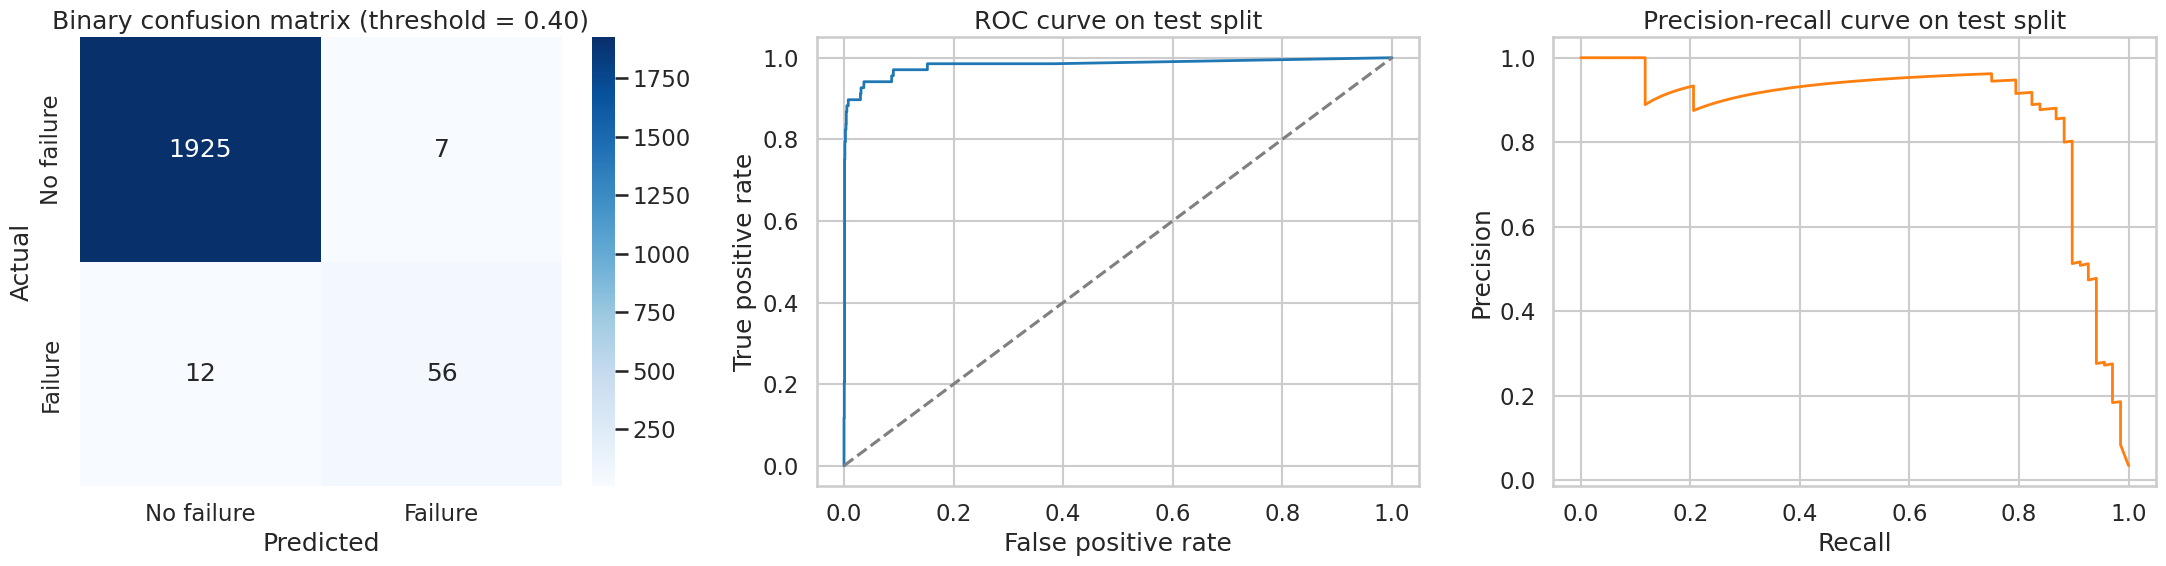


        **Binary task summary**

        - Final candidate: `Random Forest` with `Engineered features`.
        - Validation-selected threshold: **0.40**
        - Test ROC-AUC: **0.982**
        - Test PR-AUC: **0.874**
        - Test F1: **0.855**
        - Test precision: **0.889**
        - Test recall: **0.824**
        

In [14]:
# Tune the deployment threshold on validation predictions only, then evaluate that choice on the untouched test split.

threshold_table = tune_threshold(
    selected_binary_run["y_val"],
    selected_binary_run["val_prob"],
)
best_threshold = float(threshold_table.iloc[0]["Threshold"])

# Compare the default 0.50 cutoff against the validation-selected threshold.
binary_test_metrics_default = binary_metrics(
    selected_binary_run["y_test"],
    selected_binary_run["test_prob"],
    threshold=0.50,
)
binary_test_metrics_tuned = binary_metrics(
    selected_binary_run["y_test"],
    selected_binary_run["test_prob"],
    threshold=best_threshold,
)

tuned_binary_predictions = (selected_binary_run["test_prob"] >= best_threshold).astype(int)
binary_confusion = confusion_matrix(selected_binary_run["y_test"], tuned_binary_predictions)

summary_table = pd.DataFrame(
    [
        {"Setting": "Default threshold 0.50", **binary_test_metrics_default},
        {"Setting": f"Tuned threshold {best_threshold:.2f}", **binary_test_metrics_tuned},
    ]
)

display(threshold_table.head(10))
display(summary_table)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

plot_confusion(
    axes[0],
    binary_confusion,
    labels=["No failure", "Failure"],
    title=f"Binary confusion matrix (threshold = {best_threshold:.2f})",
)

fpr, tpr, _ = roc_curve(selected_binary_run["y_test"], selected_binary_run["test_prob"])
axes[1].plot(fpr, tpr, color="tab:blue", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC curve on test split")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")

precision_vals, recall_vals, _ = precision_recall_curve(
    selected_binary_run["y_test"],
    selected_binary_run["test_prob"],
)
axes[2].plot(recall_vals, precision_vals, color="tab:orange", linewidth=2)
axes[2].set_title("Precision-recall curve on test split")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.show()

display(
    Markdown(
        f"""
        **Binary task summary**

        - Final candidate: `{selected_binary_row['Model']}` with `{selected_binary_row['Feature set']}`.
        - Validation-selected threshold: **{best_threshold:.2f}**
        - Test ROC-AUC: **{binary_test_metrics_tuned['ROC-AUC']:.3f}**
        - Test PR-AUC: **{binary_test_metrics_tuned['PR-AUC']:.3f}**
        - Test F1: **{binary_test_metrics_tuned['F1']:.3f}**
        - Test precision: **{binary_test_metrics_tuned['Precision']:.3f}**
        - Test recall: **{binary_test_metrics_tuned['Recall']:.3f}**
        """
    )
)


,Feature,Importance
0,Rotational speed [rpm],0.3109
1,Temp diff [K],0.2173
2,Wear x Torque,0.1449
3,Power [W],0.1044
4,Tool wear [min],0.0284
5,Torque [Nm],0.0246
6,Type,0.0230
7,Air temperature [K],-0.0205
8,Process temperature [K],-0.0214


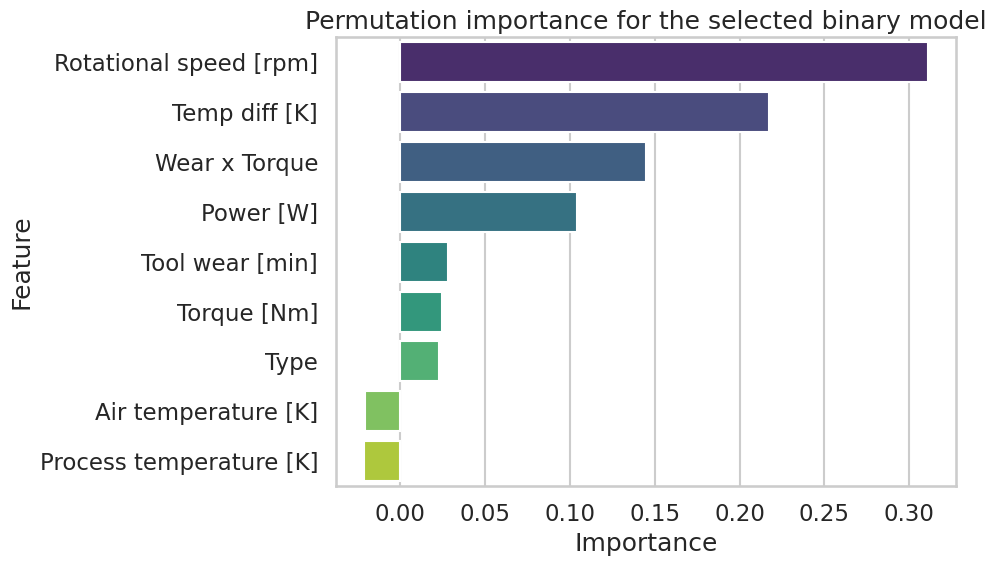


        **Interpretation note**

        Negative permutation-importance values (seen here for `Air temperature [K]` and `Process temperature [K]`) indicate that shuffling the feature slightly *improved* the score. They do not mean the variable is harmful in any causal sense; instead they reflect that the raw temperature columns contribute mostly noise once the engineered `Temp diff [K]` and `Power [W]` variables have already captured the useful thermal and energy signal.
        

In [15]:
# Measure how much each selected-model feature matters to average precision when shuffled on the test split.

permutation = permutation_importance(
    estimator=selected_binary_run["pipeline"],
    X=selected_binary_run["X_test"],
    y=selected_binary_run["y_test"],
    n_repeats=6,
    random_state=RANDOM_STATE,
    scoring="average_precision",
    n_jobs=1,
)

permutation_frame = (
    pd.DataFrame(
        {
            "Feature": selected_binary_run["X_test"].columns,
            "Importance": permutation.importances_mean,
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(permutation_frame)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=permutation_frame.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
)
plt.title("Permutation importance for the selected binary model")
plt.tight_layout()
plt.show()
display(
    Markdown(
        """
        **Interpretation note**

        Negative permutation-importance values (seen here for `Air temperature [K]` and `Process temperature [K]`) indicate that shuffling the feature slightly *improved* the score. They do not mean the variable is harmful in any causal sense; instead they reflect that the raw temperature columns contribute mostly noise once the engineered `Temp diff [K]` and `Power [W]` variables have already captured the useful thermal and energy signal.
        """
    )
)


## 4. Binary error analysis, SHAP dependence, and counterfactual recourse

Aggregate performance metrics are strong, but operational deployment would still depend on how the classifier behaves across machine types, how feature effects evolve across the risk surface, and what actions could plausibly move a high-risk case below the deployment threshold. The next cells therefore inspect subgroup-level performance, extend SHAP to **dependence diagnostics**, and perform **action-oriented counterfactual recourse analysis** for a difficult test case.

The SHAP code operates on the transformed feature matrix produced by the fitted pipeline and then regroups those contributions back to the original feature families so the explanation remains readable.


,Type,Rows,Failures,Predicted failures,Precision,Recall,F1,Balanced Accuracy
0,H,198,3,5,0.4000,0.6667,0.5000,0.8256
1,L,1179,41,38,0.9211,0.8537,0.8861,0.9255
2,M,623,24,20,0.9500,0.7917,0.8636,0.8950


,Outcome,Rows
0,True negative,1925
1,True positive,56
2,False negative,12
3,False positive,7


Outcome,Type,False negative,False positive,True negative,True positive
0,H,1,3,192,2
1,L,6,3,1135,35
2,M,5,1,598,19


,Type,Predicted probability,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
4778,H,0.3966,303.6000,312.2000,1371,54.6000,112
7884,L,0.3618,300.8000,312.4000,1465,59.1000,91
586,L,0.3500,297.6000,309.6000,1501,49.8000,222
1492,M,0.3368,298.0000,308.7000,1479,58.5000,176
4385,L,0.2532,301.8000,309.7000,1442,45.3000,233


,Type,Predicted probability,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
4231,L,0.9224,302.2000,310.8000,1340,47.8000,54
3794,M,0.8924,302.2000,310.8000,1356,48.3000,36
4898,H,0.5647,303.6000,312.4000,1460,53.7000,214
2705,L,0.4419,299.7000,309.2000,1326,64.8000,71
2492,H,0.4394,299.0000,308.8000,1382,58.5000,199


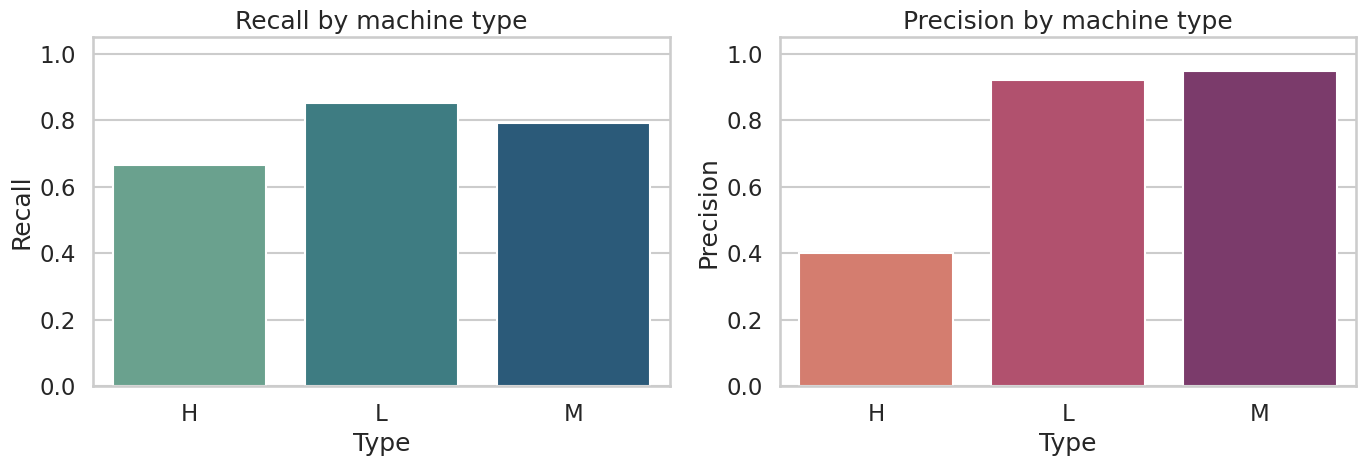


        **Operational interpretation**

        - Best recall on the test split occurred for type `L` at **0.854**.
        - Lowest recall occurred for type `H` at **0.667**.
        - The remaining false negatives deserve attention because they represent missed failures even after threshold tuning.
        - The highest-confidence false positives indicate where a preventive-maintenance policy would trade extra inspections for earlier warning.
        

In [16]:
# Attach predictions back to the test rows so each error can be reviewed in the original feature space.

binary_test_frame = selected_binary_run["X_test"].copy()
binary_test_frame["Actual"] = selected_binary_run["y_test"].values
binary_test_frame["Predicted probability"] = selected_binary_run["test_prob"]
binary_test_frame["Predicted"] = tuned_binary_predictions

# Make the TP / FP / FN / TN categories explicit for subgroup and case-level analysis.
binary_test_frame["Outcome"] = np.select(
    [
        (binary_test_frame["Actual"] == 1) & (binary_test_frame["Predicted"] == 1),
        (binary_test_frame["Actual"] == 0) & (binary_test_frame["Predicted"] == 1),
        (binary_test_frame["Actual"] == 1) & (binary_test_frame["Predicted"] == 0),
    ],
    ["True positive", "False positive", "False negative"],
    default="True negative",
)

binary_type_rows = []

# Summarize thresholded performance by machine type to check whether one product family is systematically harder.
for machine_type, group in binary_test_frame.groupby("Type"):
    group_metrics = threshold_metrics_frame(group["Actual"], group["Predicted"])
    binary_type_rows.append(
        {
            "Type": machine_type,
            "Rows": len(group),
            "Failures": int(group["Actual"].sum()),
            "Predicted failures": int(group["Predicted"].sum()),
            **group_metrics,
        }
    )

binary_type_summary = (
    pd.DataFrame(binary_type_rows)
    .sort_values("Type")
    .reset_index(drop=True)
)

outcome_counts = (
    binary_test_frame["Outcome"]
    .value_counts()
    .rename_axis("Outcome")
    .reset_index(name="Rows")
)
error_profile = (
    binary_test_frame.groupby(["Type", "Outcome"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Pull a few high-confidence misses and false alarms for qualitative inspection.
false_negative_examples = (
    binary_test_frame[binary_test_frame["Outcome"] == "False negative"][
        [
            "Type",
            "Predicted probability",
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
        ]
    ]
    .sort_values("Predicted probability", ascending=False)
    .head(5)
)
false_positive_examples = (
    binary_test_frame[binary_test_frame["Outcome"] == "False positive"][
        [
            "Type",
            "Predicted probability",
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
        ]
    ]
    .sort_values("Predicted probability", ascending=False)
    .head(5)
)

display(binary_type_summary)
display(outcome_counts)
display(error_profile)
display(false_negative_examples)
display(false_positive_examples)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=binary_type_summary, x="Type", y="Recall", hue="Type", palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Recall by machine type")
axes[0].set_ylim(0, 1.05)
sns.barplot(data=binary_type_summary, x="Type", y="Precision", hue="Type", palette="flare", legend=False, ax=axes[1])
axes[1].set_title("Precision by machine type")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

best_recall_type = binary_type_summary.sort_values(["Recall", "Precision"], ascending=False).iloc[0]
lowest_recall_type = binary_type_summary.sort_values(["Recall", "Precision"], ascending=[True, False]).iloc[0]
display(
    Markdown(
        f"""
        **Operational interpretation**

        - Best recall on the test split occurred for type `{best_recall_type['Type']}` at **{best_recall_type['Recall']:.3f}**.
        - Lowest recall occurred for type `{lowest_recall_type['Type']}` at **{lowest_recall_type['Recall']:.3f}**.
        - The remaining false negatives deserve attention because they represent missed failures even after threshold tuning.
        - The highest-confidence false positives indicate where a preventive-maintenance policy would trade extra inspections for earlier warning.
        """
    )
)


,Feature group,Mean |SHAP|
0,Rotational speed [rpm],0.1093
1,Power [W],0.0948
2,Torque [Nm],0.0866
3,Wear x Torque,0.0659
4,Temp diff [K],0.0640
5,Tool wear [min],0.0547
6,Air temperature [K],0.0285
7,Process temperature [K],0.0175
8,Type,0.0093


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp diff [K],Power [W],Wear x Torque,Actual,Predicted probability,Predicted label @ F1 threshold,Outcome
4778,H,303.6000,312.2000,1371,54.6000,112,8.6000,"7,838.9648","6,115.2000",1,0.3966,0,False negative


,Feature,SHAP,|SHAP|
0,num__Process temperature [K],-0.1384,0.1384
1,num__Rotational speed [rpm],0.1372,0.1372
2,num__Temp diff [K],0.0827,0.0827
3,num__Wear x Torque,-0.0814,0.0814
4,num__Tool wear [min],-0.0471,0.0471
5,num__Power [W],-0.0455,0.0455
6,num__Air temperature [K],0.0279,0.0279
7,cat__Type_H,-0.0196,0.0196
8,cat__Type_L,-0.0149,0.0149
9,cat__Type_M,-0.0030,0.0030


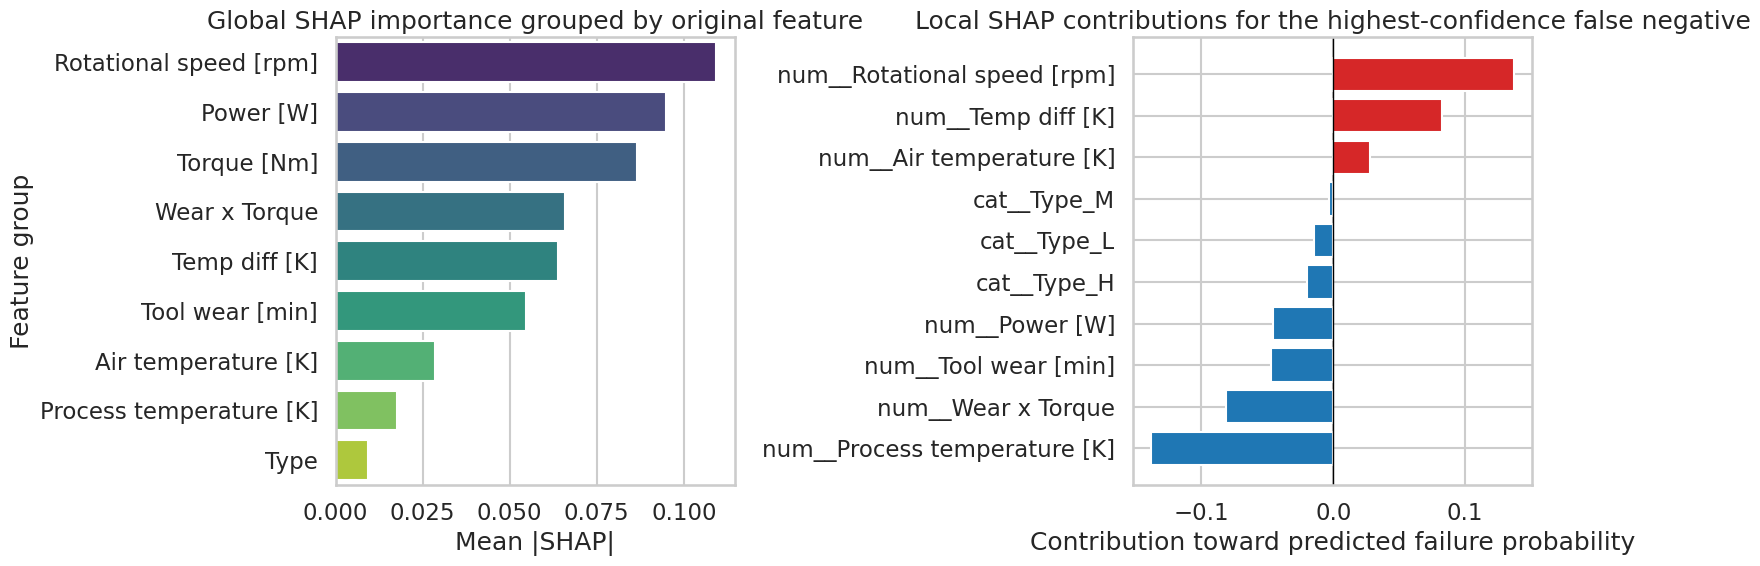

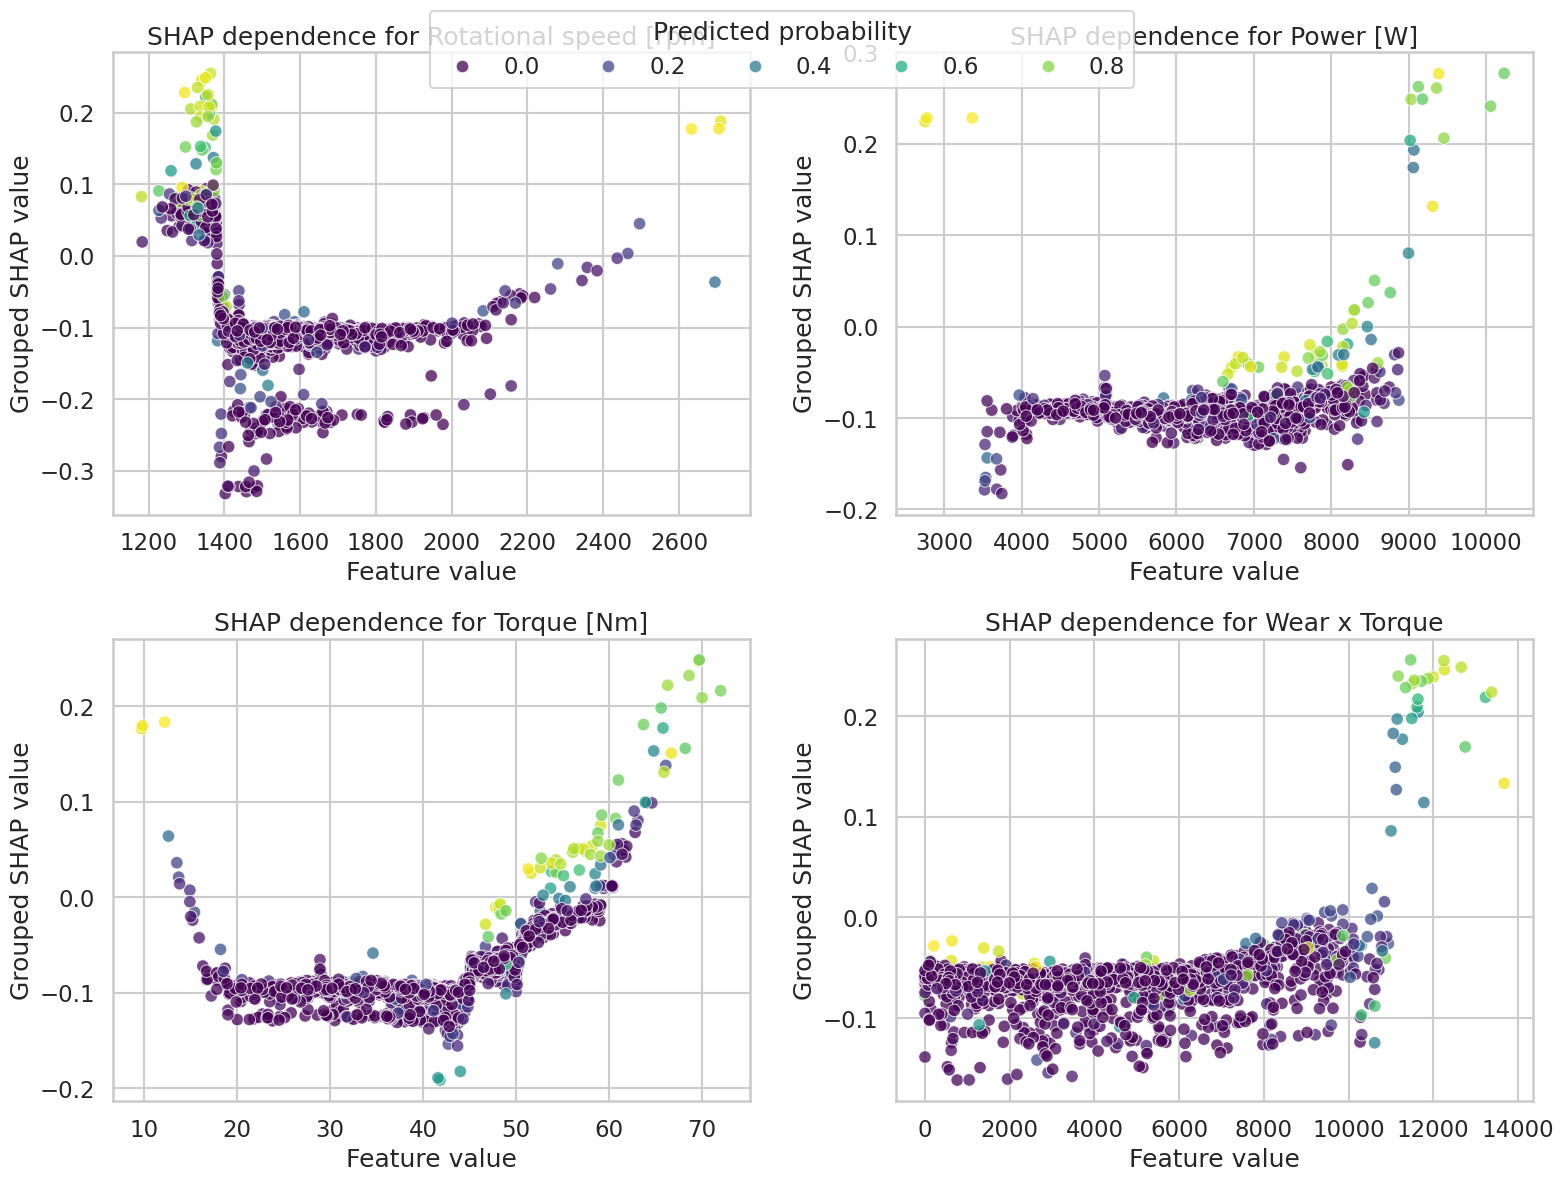

,Deployment policy,Deployment threshold,Case index,Baseline predicted probability
0,F1-tuned threshold,0.4000,7011,0.9768


,Current value
Type,L
Air temperature [K],300.5000
Process temperature [K],310.5000
Rotational speed [rpm],2633
Torque [Nm],12.2000
Tool wear [min],17


,Features changed,Counterfactual probability,Probability reduction,Intervention score,Action plan
0,Rotational speed [rpm],0.3551,0.6217,7.7214,Reduce rotational speed (2633 -> 1364 rpm).
1,"Rotational speed [rpm], Tool wear [min]",0.3583,0.6185,7.7764,Reduce rotational speed (2633 -> 1364 rpm). Re...
2,"Rotational speed [rpm], Tool wear [min]",0.3554,0.6215,7.8540,Reduce rotational speed (2633 -> 1364 rpm). Re...
3,Rotational speed [rpm],0.3517,0.6251,7.9161,Reduce rotational speed (2633 -> 1332 rpm).
4,"Rotational speed [rpm], Process temperature [K]",0.3519,0.6249,7.9475,Reduce rotational speed (2633 -> 1364 rpm). Lo...


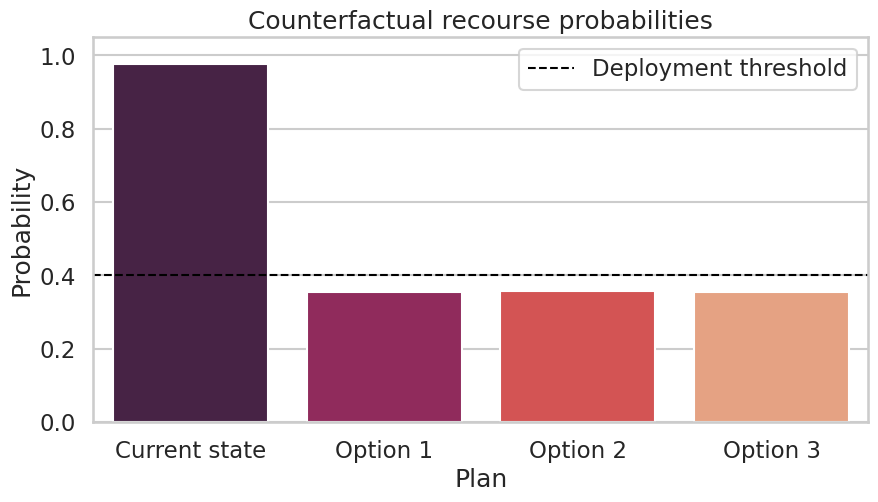


        **SHAP and recourse interpretation**

        - The strongest global SHAP drivers were led by `Rotational speed [rpm]`, `Power [W]`, and `Torque [Nm]`.
        
        - The recourse table translates model output into concrete operational changes, such as tool replacement or torque/speed adjustment, rather than leaving the explanation at feature attribution alone.
        

In [ ]:
# Build SHAP explanations on the transformed design matrix produced by the fitted preprocessing pipeline.

selected_binary_preprocess = selected_binary_run["pipeline"].named_steps["preprocess"]
selected_binary_model = selected_binary_run["pipeline"].named_steps["model"]
transformed_binary_train = selected_binary_preprocess.transform(selected_binary_run["X_train"])
transformed_binary_test = selected_binary_preprocess.transform(selected_binary_run["X_test"])
transformed_binary_feature_names = np.array(selected_binary_preprocess.get_feature_names_out())

binary_shap_explainer = build_binary_shap_explainer(
    selected_binary_model,
    transformed_binary_train,
)
binary_shap_values = positive_class_shap_values(
    binary_shap_explainer,
    transformed_binary_test,
)

# Group one-hot encoded SHAP contributions back to original feature families for a cleaner global ranking.
grouped_shap_matrix, shap_grouped_frame = grouped_shap_frame(
    binary_shap_values,
    transformed_binary_feature_names,
)

# Prefer a hard false negative for the local explanation; otherwise inspect the highest-risk predicted case.
if (binary_test_frame["Outcome"] == "False negative").any():
    shap_case_label = "highest-confidence false negative"
    shap_case_index = (
        binary_test_frame[binary_test_frame["Outcome"] == "False negative"]
        .sort_values("Predicted probability", ascending=False)
        .index[0]
    )
else:
    shap_case_label = "highest-confidence predicted failure"
    shap_case_index = (
        binary_test_frame.sort_values("Predicted probability", ascending=False).index[0]
    )

shap_case_position = selected_binary_run["X_test"].index.get_loc(shap_case_index)
shap_case_feature_frame = (
    pd.DataFrame(
        {
            "Feature": transformed_binary_feature_names,
            "SHAP": binary_shap_values[shap_case_position],
        }
    )
    .assign(**{"|SHAP|": lambda frame: frame["SHAP"].abs()})
    .sort_values("|SHAP|", ascending=False)
    .reset_index(drop=True)
)

# Snapshot the explained row in raw units so the local SHAP bars have operational context.
shap_case_snapshot = selected_binary_run["X_test"].loc[[shap_case_index]].copy()
shap_case_snapshot["Actual"] = selected_binary_run["y_test"].loc[shap_case_index]
shap_case_snapshot["Predicted probability"] = selected_binary_run["test_prob"][selected_binary_run["X_test"].index.get_loc(shap_case_index)]
shap_case_snapshot["Predicted probability"] = selected_binary_run["test_prob"][selected_binary_run["X_test"].index.get_loc(shap_case_index)]
shap_case_snapshot["Predicted label @ F1 threshold"] = int(tuned_binary_predictions[selected_binary_run["X_test"].index.get_loc(shap_case_index)])
shap_case_snapshot["Outcome"] = binary_test_frame.loc[shap_case_index, "Outcome"]

display(shap_grouped_frame)
display(shap_case_snapshot)
display(shap_case_feature_frame.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=shap_grouped_frame.head(10),
    x="Mean |SHAP|",
    y="Feature group",
    hue="Feature group",
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Global SHAP importance grouped by original feature")

local_plot = shap_case_feature_frame.head(10).sort_values("SHAP")
local_colors = ["tab:red" if value > 0 else "tab:blue" for value in local_plot["SHAP"]]
axes[1].barh(local_plot["Feature"], local_plot["SHAP"], color=local_colors)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Local SHAP contributions for the {shap_case_label}")
axes[1].set_xlabel("Contribution toward predicted failure probability")

plt.tight_layout()
plt.show()

numeric_dependence_features = [
    feature_name
    for feature_name in shap_grouped_frame["Feature group"]
    if feature_name in selected_binary_run["X_test"].select_dtypes(include=["number"]).columns
][:4]

# Limit dependence plots to a few top numeric drivers so the notebook stays readable.
if numeric_dependence_features:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    for axis, feature_name in zip(axes, numeric_dependence_features):
        dependence_frame = pd.DataFrame(
            {
                "Feature value": selected_binary_run["X_test"][feature_name].values,
                "Grouped SHAP value": grouped_shap_matrix[feature_name].values,
                "Predicted probability": selected_binary_run["test_prob"],
            }
        )
        sns.scatterplot(
            data=dependence_frame,
            x="Feature value",
            y="Grouped SHAP value",
            hue="Predicted probability",
            palette="viridis",
            alpha=0.75,
            ax=axis,
        )
        axis.set_title(f"SHAP dependence for {feature_name}")
        if axis.legend_ is not None:
            axis.legend_.remove()

    for axis in axes[len(numeric_dependence_features):]:
        axis.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title="Predicted probability", loc="upper center", ncol=5)
    plt.tight_layout()
    plt.show()

binary_raw_test = df.loc[selected_binary_run["X_test"].index, SENSOR_FEATURES].copy()
high_risk_mask = pd.Series(selected_binary_run["test_prob"], index=selected_binary_run["X_test"].index) >= best_threshold
if high_risk_mask.any():
    recourse_case_index = pd.Series(selected_binary_run["test_prob"], index=selected_binary_run["X_test"].index)[high_risk_mask].sort_values(ascending=False).index[0]
else:
    recourse_case_index = pd.Series(selected_binary_run["test_prob"], index=selected_binary_run["X_test"].index).sort_values(ascending=False).index[0]

recourse_raw_row = binary_raw_test.loc[recourse_case_index]
recourse_baseline_frame = build_feature_frame(
    recourse_raw_row.to_frame().T,
    selected_binary_row["Feature set"],
)[selected_binary_run["X_train"].columns]
recourse_baseline_probability = float(selected_binary_run["pipeline"].predict_proba(recourse_baseline_frame)[:, 1][0])

# Search for compact one- or two-feature interventions that push the case below the deployment threshold.
recourse_options = search_counterfactual_recourse(
    estimator=selected_binary_run["pipeline"],
    raw_row=recourse_raw_row,
    reference_raw_frame=df[SENSOR_FEATURES],
    feature_set_name=selected_binary_row["Feature set"],
    model_columns=selected_binary_run["X_train"].columns.tolist(),
    target_threshold=best_threshold,
    max_features_to_change=2,
)

display(
    pd.DataFrame(
        [
            {
                "Deployment policy": "F1-tuned threshold",
                "Deployment threshold": best_threshold,
                "Case index": recourse_case_index,
                "Baseline predicted probability": recourse_baseline_probability,
            }
        ]
    )
)
display(recourse_raw_row.to_frame(name="Current value"))
display(recourse_options.head(5))

if not recourse_options.empty and recourse_options["Counterfactual probability"].notna().any():
    # Compare the current predicted risk against the strongest counterfactual options found by the search.
    recourse_plot_frame = recourse_options.head(3).copy()
    recourse_plot_frame["Plan"] = [f"Option {index + 1}" for index in range(len(recourse_plot_frame))]
    recourse_plot_frame = pd.concat(
        [
            pd.DataFrame([{"Plan": "Current state", "Probability": recourse_baseline_probability}]),
            recourse_plot_frame[["Plan", "Counterfactual probability"]].rename(columns={"Counterfactual probability": "Probability"}),
        ],
        ignore_index=True,
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(data=recourse_plot_frame, x="Plan", y="Probability", hue="Plan", palette="rocket", legend=False)
    plt.axhline(best_threshold, linestyle="--", color="black", linewidth=1.5, label="Deployment threshold")
    plt.ylim(0, 1.05)
    plt.title("Counterfactual recourse probabilities")
    plt.legend()
    plt.show()

display(
    Markdown(
        f"""
        **SHAP and recourse interpretation**

        - The strongest global SHAP drivers were led by `{shap_grouped_frame.iloc[0]['Feature group']}`, `{shap_grouped_frame.iloc[1]['Feature group']}`, and `{shap_grouped_frame.iloc[2]['Feature group']}`.

        - The recourse table translates model output into concrete operational changes, such as tool replacement or torque/speed adjustment, rather than leaving the explanation at feature attribution alone.
        """
    )
)


## 5. Multiclass modeling: predicting the failure cause

The secondary task predicts the failure cause only on a cleaned subset of failure rows. This is necessary because the raw failure-mode columns are not a clean single-label target:

- some failed rows have **zero** active failure labels,
- some failed rows have **multiple** active failure labels,
- the `RNF` flag is inconsistent with `Machine failure` in most of the rows where it appears.

To keep the multiclass task defensible, only rows meeting all of the following conditions are retained:

1. `Machine failure == 1`
2. exactly one of `TWF`, `HDF`, `PWF`, `OSF` is active
3. `RNF == 0`

The next code cells make that cleaning rule audit-friendly by reporting each excluded subgroup before any multiclass model is fit.


In [17]:
# Build the cleaned failure-only table used for the defensible multiclass task.

clean_failure_df, multiclass_exclusion_summary = build_clean_failure_subset(df)
multiclass_features = add_engineered_features(clean_failure_df[SENSOR_FEATURES].copy())
multiclass_target = clean_failure_df["Failure cause"].copy()

multiclass_class_counts = (
    multiclass_target.value_counts()
    .rename_axis("Failure cause")
    .reset_index(name="Rows")
)

display(multiclass_exclusion_summary)
display(multiclass_class_counts)


,Stage,Rows
0,Total dataset rows,10000
1,Rows with Machine failure = 1,339
2,Retained clean single-cause failures,306
3,Excluded failure rows with zero non-RNF cause ...,9
4,Excluded failure rows with multiple non-RNF ca...,23
5,Excluded failure rows with RNF flagged,1
6,RNF-marked rows with Machine failure = 0 (desc...,18


,Failure cause,Rows
0,HDF,106
1,PWF,80
2,OSF,78
3,TWF,42


In [18]:
# Split the cleaned failure subset once and compare two model families on exactly the same rows.

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    multiclass_features,
    multiclass_target,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=multiclass_target,
)

multiclass_models = build_multiclass_models(num_classes=y_train_mc.nunique())
multiclass_runs = {}
multiclass_rows = []
class_names = sorted(y_train_mc.unique())
class_to_int = {label: idx for idx, label in enumerate(class_names)}
int_to_class = {idx: label for label, idx in class_to_int.items()}

for model_name, model in multiclass_models.items():
    pipeline = make_pipeline(X_train_mc, model)
    if model_name == "Multiclass XGBoost":
        # XGBoost's multi:softprob objective expects integer-coded labels instead of the original strings.
        y_train_model = y_train_mc.map(class_to_int)
        pipeline.fit(X_train_mc, y_train_model)
        encoded_predictions = pipeline.predict(X_test_mc)
        predictions = pd.Series(
            [int_to_class[int(value)] for value in encoded_predictions],
            index=y_test_mc.index,
        )
    else:
        pipeline.fit(X_train_mc, y_train_mc)
        predictions = pd.Series(pipeline.predict(X_test_mc), index=y_test_mc.index)
    report = report_frame(y_test_mc, predictions)
    macro_f1 = float(report.loc[report["Class"] == "macro avg", "f1-score"].iloc[0])
    weighted_f1 = float(report.loc[report["Class"] == "weighted avg", "f1-score"].iloc[0])
    accuracy = float(report.loc[report["Class"] == "accuracy", "f1-score"].iloc[0])

    multiclass_rows.append(
        {
            "Model": model_name,
            "Macro F1": macro_f1,
            "Weighted F1": weighted_f1,
            "Accuracy": accuracy,
        }
    )

    multiclass_runs[model_name] = {
        "pipeline": pipeline,
        "predictions": predictions,
        "report": report,
    }


,Model,Macro F1,Weighted F1,Accuracy
0,Multiclass XGBoost,0.9644,0.9673,0.9677
1,Multinomial Logistic Regression,0.9289,0.9354,0.9355


,Class,Precision,Recall,F1,Support
0,HDF,0.9545,1.0000,0.9767,21.0000
1,OSF,1.0000,0.8750,0.9333,16.0000
2,PWF,1.0000,1.0000,1.0000,16.0000
3,TWF,0.9000,1.0000,0.9474,9.0000
4,accuracy,NaN,NaN,0.9677,62.0000
5,macro avg,0.9636,0.9688,0.9644,62.0000
6,weighted avg,0.9701,0.9677,0.9673,62.0000


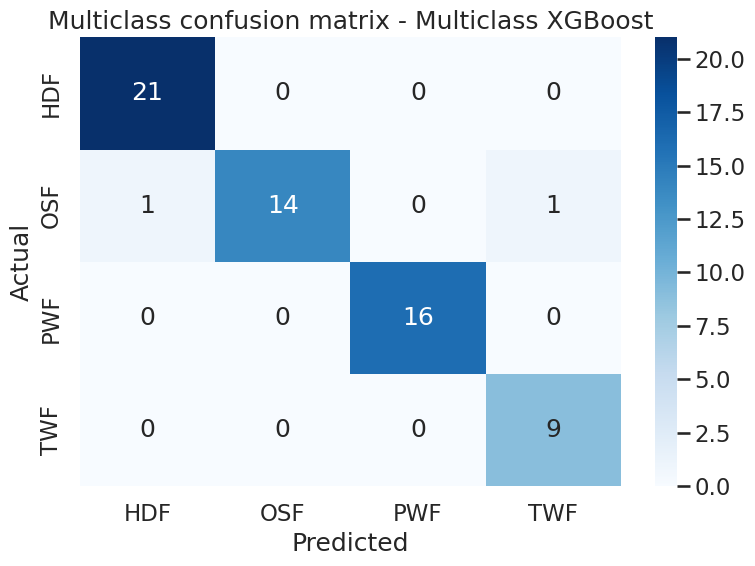


        **Multiclass task summary**

        - Final multiclass model: `Multiclass XGBoost`
        - Test macro F1: **0.964**
        - Test weighted F1: **0.967**
        - Classes modeled: `HDF, OSF, PWF, TWF`

        The high accuracy reflects the fact that, after label cleaning, each retained row obeys exactly one of the deterministic AI4I failure rules described by Matzka (2020). The model is therefore recovering an underlying data-generating rule rather than generalizing over ambiguous cases, and the metrics on this cleaned subset should be read as an upper bound rather than as a realistic estimate of field performance on noisier production labels.
        

In [19]:
# Select the multiclass model by macro F1 so smaller failure classes count equally in the decision.

multiclass_results = (
    pd.DataFrame(multiclass_rows)
    .sort_values(["Macro F1", "Weighted F1"], ascending=False)
    .reset_index(drop=True)
)

selected_multiclass_model_name = multiclass_results.iloc[0]["Model"]
selected_multiclass_run = multiclass_runs[selected_multiclass_model_name]
multiclass_confusion = confusion_matrix(
    y_test_mc,
    selected_multiclass_run["predictions"],
    labels=sorted(y_test_mc.unique()),
)

display(multiclass_results)
display(
    selected_multiclass_run["report"].rename(
        columns={
            "precision": "Precision",
            "recall": "Recall",
            "f1-score": "F1",
            "support": "Support",
        }
    )
)

plt.figure(figsize=(8, 6))
plot_confusion(
    plt.gca(),
    multiclass_confusion,
    labels=sorted(y_test_mc.unique()),
    title=f"Multiclass confusion matrix - {selected_multiclass_model_name}",
)
plt.tight_layout()
plt.show()

display(
    Markdown(
        f"""
        **Multiclass task summary**

        - Final multiclass model: `{selected_multiclass_model_name}`
        - Test macro F1: **{multiclass_results.iloc[0]['Macro F1']:.3f}**
        - Test weighted F1: **{multiclass_results.iloc[0]['Weighted F1']:.3f}**
        - Classes modeled: `{', '.join(sorted(y_test_mc.unique()))}`

        The high accuracy reflects the fact that, after label cleaning, each retained row obeys exactly one of the deterministic AI4I failure rules described by Matzka (2020). The model is therefore recovering an underlying data-generating rule rather than generalizing over ambiguous cases, and the metrics on this cleaned subset should be read as an upper bound rather than as a realistic estimate of field performance on noisier production labels.
        """
    )
)


,Feature,Importance
0,num__Temp diff [K],0.2147
1,num__Power [W],0.1777
2,num__Torque [Nm],0.1698
3,num__Wear x Torque,0.1571
4,num__Tool wear [min],0.0858
5,num__Air temperature [K],0.0656
6,num__Rotational speed [rpm],0.0493
7,cat__Type_H,0.0413
8,num__Process temperature [K],0.0207
9,cat__Type_L,0.0177


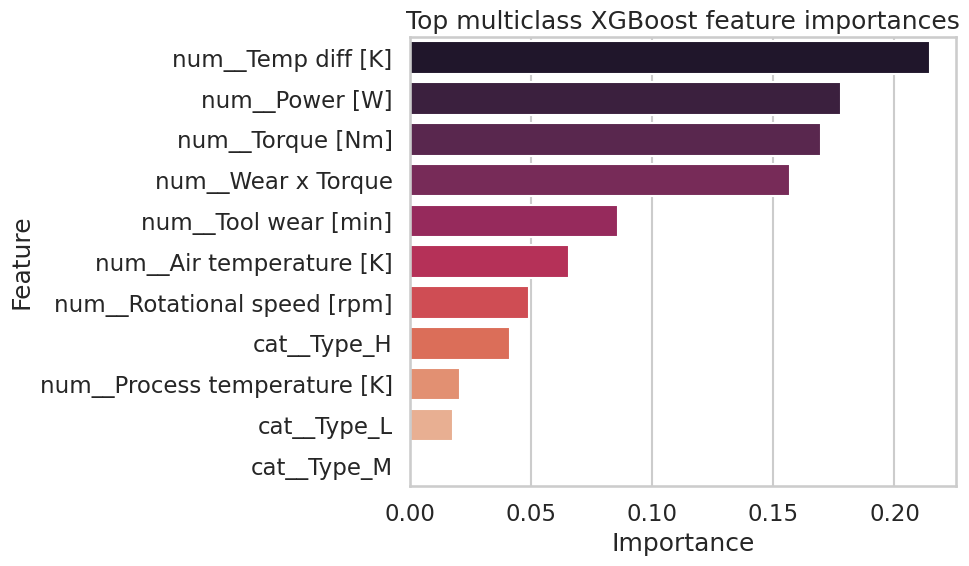

In [20]:
# Inspect the learned drivers of the chosen multiclass model using the explanation that fits its model family.

multiclass_pipeline = selected_multiclass_run["pipeline"]
multiclass_preprocess = multiclass_pipeline.named_steps["preprocess"]
multiclass_model = multiclass_pipeline.named_steps["model"]
transformed_feature_names = multiclass_preprocess.get_feature_names_out()

if selected_multiclass_model_name == "Multinomial Logistic Regression":
    # Logistic regression is most naturally interpreted through its class-specific coefficients.
    coefficient_strength = np.abs(multiclass_model.coef_).mean(axis=0)
    coefficient_frame = (
        pd.DataFrame(
            {
                "Feature": transformed_feature_names,
                "Mean absolute coefficient": coefficient_strength,
            }
        )
        .sort_values("Mean absolute coefficient", ascending=False)
        .reset_index(drop=True)
    )
    display(coefficient_frame.head(12))
    display(top_coefficient_table(multiclass_pipeline, top_n=5))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=coefficient_frame.head(12),
        x="Mean absolute coefficient",
        y="Feature",
        hue="Feature",
        palette="magma",
        legend=False,
    )
    plt.title("Top multiclass logistic-regression coefficients")
    plt.tight_layout()
    plt.show()
else:
    # Tree boosting is summarized via built-in feature importances rather than coefficients.
    importance_frame = (
        pd.DataFrame(
            {
                "Feature": transformed_feature_names,
                "Importance": multiclass_model.feature_importances_,
            }
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    display(importance_frame.head(12))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_frame.head(12),
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="rocket",
        legend=False,
    )
    plt.title("Top multiclass XGBoost feature importances")
    plt.tight_layout()
    plt.show()


## Conclusion

The key findings from the experiments above are summarized below.

In [21]:
# Consolidate the main report findings in one markdown block for the written submission.

display(
    Markdown(
        f"""
         **Key findings**

        - The best model was {selected_binary_row['Model']} using engineered features.
        - It performed well on new data, catching most failures with few false alarms using a threshold of {best_threshold:.2f}.
        - Adding physics-based features (temperature difference, power, wear × torque) improved all models.
        - Key factors behind failures are speed and mechanical stress, though feature rankings can vary.
        - The model works well across machine types, but missing failures is still the biggest concern.
        - Predicting failure types worked very well after cleaning the data, mainly because the dataset follows simple rules.
        - Time-based methods were not used since the data does not include machine history.
        - Sequence-aware and survival-analysis methods are deferred to future work because the AI4I table is cross-sectional and has no repeated, timestamped per-asset trajectories or censoring information.
        """
    )
)



         **Key findings**

        - The best model was Random Forest using engineered features.
        - It performed well on new data, catching most failures with few false alarms using a threshold of 0.40.
        - Adding physics-based features (temperature difference, power, wear × torque) improved all models.
        - Key factors behind failures are speed and mechanical stress, though feature rankings can vary.
        - The model works well across machine types, but missing failures is still the biggest concern.
        - Predicting failure types worked very well after cleaning the data, mainly because the dataset follows simple rules.
        - Time-based methods were not used since the data does not include machine history.
        - Sequence-aware and survival-analysis methods are deferred to future work because the AI4I table is cross-sectional and has no repeated, timestamped per-asset trajectories or censoring information.
        

## Challenges, limitations, contribution table, and references

- The dataset has very few failure cases, so normal accuracy can be misleading. That’s why we focused on better measures like precision, recall, and PR-AUC, and adjusted the decision threshold.
- The failure types in the data are not always clear or consistent. Some rows had to be cleaned or removed before building a model to predict failure types.
- The dataset is artificially created (synthetic). It helps for testing models, but it may not fully reflect real-world conditions like noise, changing patterns, or actual factory operations.

### Future work

- Collect real machine data over time (with timestamps) so we can track how each machine behaves and detect changes more accurately.
- Use models that estimate how long a machine can keep running before it fails, so maintenance can be planned in advance instead of just reacting to a failure warning.
- Gather cost information from the factory (like inspection costs, downtime costs, and cost of missed failures) so decisions can be based on real business impact, not just model scores.

### Two-person contribution table

| Team member | Contribution summary |
| --- | --- |
| `Han Soe` | Project framing, exploratory analysis, multiclass modeling, visual design, and presentation preparation |
| `Nay Linn Aung` | Data preparation, binary modeling, notebook integration, validation checks, and final report polishing |

### References

1. S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," in 2020 Third International Conference on Artificial           Intelligence for Industries (AI4I), 2020, p. 69, doi: 10.1109/AI4I49448.2020.00023.
2. A. Torcianti and S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications using a Local Surrogate Model," in 2021 4th     International Conference on Artificial Intelligence for Industries (AI4I), 2021, p. 86, doi: 10.1109/AI4I51902.2021.00029.
3. AI4I 2020 Predictive Maintenance Dataset, UCI Machine Learning Repository.  
   https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
4. C. Shah, A Hands-On Introduction to Data Science. Cambridge, UK: Cambridge University Press, 2020.
5. Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32.
6. Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of KDD 2016*, 785-794.
7. Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*, 30.
